<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/NLP/Natural_Language_Processing_Day_31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encoder-Decoder RNN

# Auto-Regressive
In the decoder architecture each of the step is autoregressive. \
**For example** - for generating the next word, first all the previously generated words are consumed and the model generates first token.

Input
- step1 : I love llamas   -->   lk
- step2 : I love llamas lk  -->   hou
- step3 : I love llamas lk hou   --> van
- step4 : I love llamas lk hou van   --> lama's

Output : lk hou van lama's

# Transformer Encoder-Decoder
Input sentence : "I love llama's" is converted into embedding which are having randome values the encoder block has a self-attention layer which processes these embeddings and create more meaningful/contextualize informtionbecause of attention mechnism. This is then feed into feed-forward neural network.

In [ ]:
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/CDAC')
os.getcwd()

/content


'/content/drive/MyDrive/CDAC'

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.stattools import acf

In [ ]:
df=pd.read_csv("DailyDelhiClimateTrain.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [ ]:
temp=df[["meantemp"]]
temp.head()

,meantemp
0,10.000000
1,7.400000
2,7.166667
3,8.666667
4,6.000000


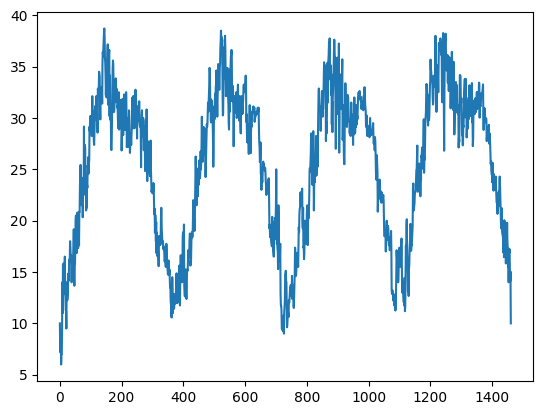

In [ ]:
plt.plot(temp)
plt.show()

In [ ]:
print(temp.shape)

(1462, 1)


In [ ]:
acf_values=acf(temp)
print(acf_values)

[1.         0.9711027  0.95095435 0.93435913 0.92457295 0.91551781
 0.90737097 0.89843343 0.89046222 0.88351839 0.87855285 0.87618765
 0.87108249 0.86575916 0.85981725 0.85384141 0.84625367 0.83890942
 0.83112316 0.82443026 0.8159426  0.80555558 0.79472453 0.78396174
 0.77645828 0.76750406 0.75910245 0.74987832 0.74150154 0.7333316
 0.72481656 0.71526761]


In [ ]:
scalar=MinMaxScaler()
scaled_temp=scalar.fit_transform(temp)

In [ ]:
look_back=30
X=[]
y=[]
for i in range(len(scaled_temp)-look_back):
    X.append(scaled_temp[i:i+look_back])
    y.append(scaled_temp[i+look_back])
X=np.array(X)
y=np.array(y)

In [ ]:
split=int(len(X)*0.8)

X_train= X[:split]
X_test=X[split:]

y_train=y[:split]
y_test=y[split:]

In [ ]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [ ]:
model=Sequential([
LSTM(units=128,return_sequences=True,input_shape=(look_back,1)),
Dropout(0.2),

LSTM(64,return_sequences=True),
Dropout(0.2),

LSTM(32),
Dropout(0.2),

Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,417 (501.63 KB)

 Trainable params: 128,417 (501.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop=keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [ ]:
history=model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.2,
                  callbacks=[early_stop])

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - loss: 0.0552 - val_loss: 0.0073
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0151 - val_loss: 0.0057
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0134 - val_loss: 0.0052
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0114 - val_loss: 0.0051
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0114 - val_loss: 0.0087
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0116 - val_loss: 0.0065
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0106 - val_loss: 0.0049
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0112 - val_loss: 0.0049
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0112 - val_loss: 0.0044
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0103 - val_loss: 0.0087
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0097 - val_loss: 0.0044
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/

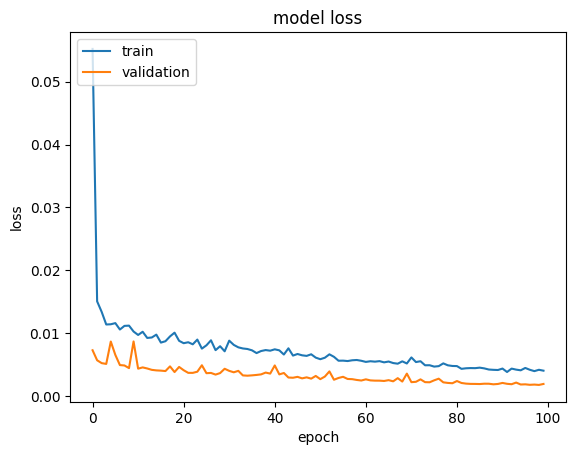

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')